# Depth-guided RIFE Refinement — стартовая заготовка

**Постановка.** Учим refinement-сеть, которая берёт выход RIFE и улучшает его, используя информацию о глубине.

- **Вход (12 каналов):** `I_0` (RGB), `I_rife` (RGB), `I_2` (RGB), `D_0`, `D_1`, `D_2`
- **Выход:** уточнённый `I_1` (RGB)
- **Цель:** residual поверх `I_rife`
- **Метрика:** PSNR (с uint8-квантованием) → **loss = MSE**

**Вводные:**
- 1278 комплектов, разрешение 1024×544
- RTX 4060 Ti
- Без внешних данных на старте

**План работы по этому ноутбуку:**
1. Sanity overfit на 16 сэмплах (проверка pipeline) — 10 минут
2. Baseline U-Net на полных данных — посмотреть прирост над чистым RIFE
3. Architecture sweep (короткие тренировки на сабсете) — выбор лучшего варианта
4. Финальное обучение с EMA + TTA + ensemble

**Colab quick start:** положи на Drive три папки (`rife_refinement_baked/train`, `final_dataset_v5_participants/train`, `rife_predictions_v5/train`), запусти CONFIG → Dataset. По умолчанию `max_samples=100`.


## 1. Imports

In [1]:
import os
import sys
import json
import math
import copy
import random
import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from PIL import Image

# Проверим, что есть GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Фиксируем сид для воспроизводимости
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

IN_COLAB = "google.colab" in sys.modules
IN_JUPYTER = "ipykernel" in sys.modules or "IPython" in sys.modules


def effective_num_workers(cfg) -> int:
    """В ноутбуке num_workers>0 часто виснет молча (Windows/Colab)."""
    if IN_COLAB or IN_JUPYTER:
        return 0
    return cfg.num_workers


def print_cuda_status(prefix: str = "") -> None:
    tag = f"[{prefix}] " if prefix else ""
    print(f"{tag}DEVICE={DEVICE}  cuda_available={torch.cuda.is_available()}", flush=True)
    if DEVICE.type == "cuda":
        print(f"{tag}GPU={torch.cuda.get_device_name(0)}", flush=True)
        alloc = torch.cuda.memory_allocated() / 1e6
        print(f"{tag}VRAM allocated={alloc:.0f} MB", flush=True)


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
Memory: 17.2 GB


## 2. CONFIG

Здесь все настройки. Подставь свои пути и параметры под датасет.


In [2]:
@dataclass
class Config:
    # === Данные ===
    # depth (.npy) — из baked; RGB/RIFE — on-the-fly
    data_root: str = r"C:/Users/adel/Downloads/cv_dataset/rife_refinement_baked/train"
    dataset_root: str = r"C:/Users/adel/Downloads/cv_dataset/final_dataset_v5_participants/train"
    rife_root: str = r"C:/Users/adel/Downloads/cv_dataset/rife_predictions_v5/train"

    # 0 = все запечённые; 100 = быстрый старт в Colab
    max_samples: int = 200

    image_h: int = 544
    image_w: int = 1024

    # === Разделение train/val ===
    val_fraction: float = 0.16  # при 100 сэмплах → ~16 val / 84 train

    # === Тренировка ===
    train_full_frame: bool = True   # True: train/val 1024×544; False: random patch
    patch_size: int = 256           # только sanity-overfit и train если full_frame=False
    cache_in_ram: bool = True       # один раз грузим jpg/npy в RAM (100 сэмплов ~3 GB)
    batch_size: int = 2             # full frame; для patches можно 8
    num_workers: int = 0

    base_channels: int = 32
    in_channels: int = 12
    out_channels: int = 3

    lr: float = 2e-4
    weight_decay: float = 5e-4
    num_epochs: int = 80        # для max_samples=100; для full: 200
    warmup_epochs: int = 5
    grad_clip: float = 1.0

    use_amp: bool = True
    amp_dtype: str = "bf16"

    use_ema: bool = True
    ema_decay: float = 0.9995

    log_every: int = 50
    val_every: int = 1
    save_dir: str = "./checkpoints"
    seed: int = 42


CFG = Config()

# --- Colab: раскомментируй и поправь пути на Drive ---
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    _DRIVE = "/content/drive/MyDrive/cv_dataset"
    CFG.data_root = f"{_DRIVE}/rife_refinement_baked/train"
    CFG.dataset_root = f"{_DRIVE}/final_dataset_v5_participants/train"
    CFG.rife_root = f"{_DRIVE}/rife_predictions_v5/train"
    CFG.max_samples = 100
    CFG.batch_size = 8
    CFG.num_workers = 0
    CFG.num_epochs = 80
    print("Colab paths applied")

Path(CFG.save_dir).mkdir(parents=True, exist_ok=True)
print(f"Config OK  max_samples={CFG.max_samples or 'all'}")


Config OK  max_samples=1000


## 3. Dataset

Берём **запечённые** папки, проверяем RGB/RIFE по `meta.json`, ограничиваем `max_samples`.

После загрузки — **`verify_samples`**: пути, размеры, PSNR(RIFE vs GT), превью t0/RIFE/target/t1.


Запечено: 1278  готово к обучению: 1000
=== verify_samples: 3 комплект(а) ===



[0] 2026-03-14_07_34_35_09_12_02_ravine_1773469532300078000__001  camera=left_bwd


    baked: C:\Users\adel\Downloads\cv_dataset\rife_refinement_baked\train\2026-03-14_07_34_35_09_12_02_ravine_1773469532300078000__001


    source: C:\Users\adel\Downloads\cv_dataset\final_dataset_v5_participants\train\2026-03-14_07_34_35_09_12_02_ravine_1773469532300078000__001


    files: OK


...

    D0: valid=71.9%


    D1: valid=72.7%


    D2: valid=74.6%


    PSNR(RIFE vs GT) full frame: 18.20 dB


    PSNR(RIFE vs GT) center patch 256x256: 19.27 dB  ← sanity использует это


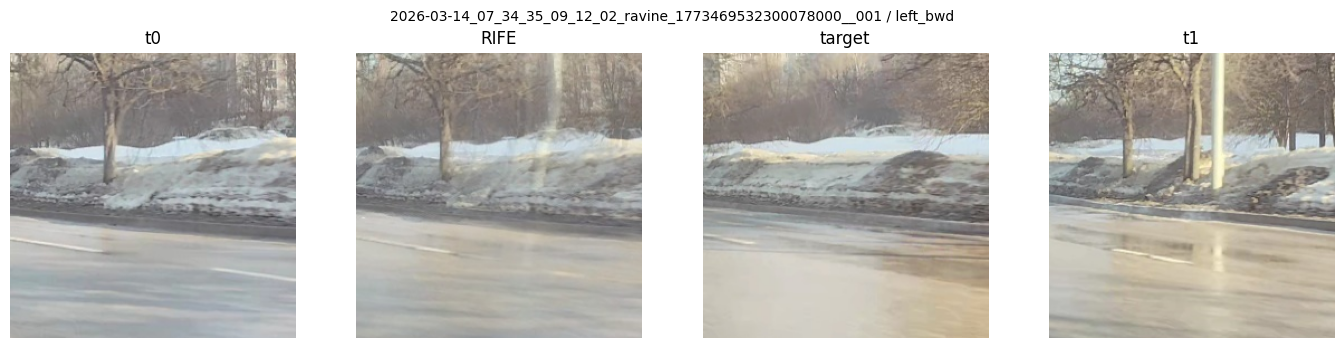


[1] 2026-03-14_18_53_24_19_40_46_mika_1773507185399647000__000  camera=front


    baked: C:\Users\adel\Downloads\cv_dataset\rife_refinement_baked\train\2026-03-14_18_53_24_19_40_46_mika_1773507185399647000__000


    source: C:\Users\adel\Downloads\cv_dataset\final_dataset_v5_participants\train\2026-03-14_18_53_24_19_40_46_mika_1773507185399647000__000


    files: OK


  RAM cache: preloading 1 samples...


...

    PSNR(RIFE vs GT) full frame: 20.07 dB



=== verify_samples OK ===


  RAM cache: preloading 1 samples...


  RAM cache: done in 0.1s

  x: (12, 256, 256), range=[0.000, 1.000], finite=True
  rife: (3, 256, 256), range=[0.345, 1.000], finite=True
  gt: (3, 256, 256), range=[0.259, 1.000], finite=True


In [3]:
def load_image_uint8(path: str) -> np.ndarray:
    """Загружаем RGB картинку → [H, W, 3] uint8."""
    img = Image.open(path).convert("RGB")
    return np.array(img)


def load_depth(path: str) -> np.ndarray:
    """Загружаем depth → [H, W] float32 в [0, 1]. NaN/invalid → 0."""
    p = Path(path)
    if p.suffix == ".npy":
        d = np.load(path).astype(np.float32)
    else:
        d = np.array(Image.open(path)).astype(np.float32)
        if d.ndim == 3:
            d = d[..., 0]
    valid = np.isfinite(d) & (d > 0)
    out = np.zeros(d.shape, dtype=np.float32)
    if not np.any(valid):
        return out
    lo, hi = float(d[valid].min()), float(d[valid].max())
    out[valid] = (d[valid] - lo) / max(hi - lo, 1e-6)
    return out


def _ensure_3ch(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr


def _resize_uint8_rgb(arr: np.ndarray, h: int, w: int) -> np.ndarray:
    if arr.shape[0] == h and arr.shape[1] == w:
        return arr
    return np.array(Image.fromarray(arr).resize((w, h), Image.BILINEAR))


def _resize_depth(arr: np.ndarray, h: int, w: int) -> np.ndarray:
    if arr.shape[0] == h and arr.shape[1] == w:
        return arr
    t = torch.from_numpy(arr.astype(np.float32))[None, None]
    t = F.interpolate(t, size=(h, w), mode="nearest")
    return t[0, 0].numpy()


class RefineDataset(Dataset):
    """
    Возвращает dict:
      x:    [12, H, W] float32 в [0, 1]
      rife: [3,  H, W] float32 в [0, 1]
      gt:   [3,  H, W] float32 в [0, 1]

    depth — из baked data_root/<id>/d*.npy
    RGB/RIFE — из dataset_root + rife_root по meta.json
    """
    def __init__(
        self,
        sample_dirs: List[Path],
        dataset_root: Path,
        rife_root: Path,
        patch_size: Optional[int] = 256,
        augment: bool = True,
        target_h: int = 544,
        target_w: int = 1024,
        fixed_crop: Optional[str] = None,
        cache_full: bool = False,
    ):
        self.dirs = sample_dirs
        self.dataset_root = Path(dataset_root)
        self.rife_root = Path(rife_root)
        self.patch_size = patch_size
        self.augment = augment
        self.target_h = target_h
        self.target_w = target_w
        self.fixed_crop = fixed_crop
        self._full_cache: Optional[list] = None
        if cache_full and len(self.dirs) > 0:
            print(f"  RAM cache: preloading {len(self.dirs)} samples...", flush=True)
            t0 = time.time()
            self._full_cache = [self._load_sample(d) for d in self.dirs]
            print(f"  RAM cache: done in {time.time()-t0:.1f}s", flush=True)

    def __len__(self):
        return len(self.dirs)

    def _load_baked_meta(self, baked_dir: Path) -> dict:
        return json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))

    def _load_rgb_path(self, path: Path) -> np.ndarray:
        return _ensure_3ch(load_image_uint8(str(path)))

    def _load_depth_npy(self, baked_dir: Path, stem: str) -> np.ndarray:
        dmap = np.load(baked_dir / f"{stem}.npy").astype(np.float32)
        valid = np.isfinite(dmap) & (dmap > 0)
        out = np.zeros(dmap.shape, dtype=np.float32)
        if not np.any(valid):
            return out
        lo, hi = float(dmap[valid].min()), float(dmap[valid].max())
        out[valid] = (dmap[valid] - lo) / max(hi - lo, 1e-6)
        return out

    def _load_sample(self, baked_dir: Path):
        meta = self._load_baked_meta(baked_dir)
        sid = meta["sample_id"]
        cam = meta["camera"]
        src = resolve_source_dir(meta, self.dataset_root)

        I0 = self._load_rgb_path(src / "input" / "t0" / f"{cam}.jpg")
        I2 = self._load_rgb_path(src / "input" / "t1" / f"{cam}.jpg")
        GT = self._load_rgb_path(src / "target" / f"{cam}.jpg")
        Ir = self._load_rgb_path(self.rife_root / f"{sid}.jpg")

        D0 = self._load_depth_npy(baked_dir, "d0")
        D1 = self._load_depth_npy(baked_dir, "d1")
        D2 = self._load_depth_npy(baked_dir, "d2")

        th, tw = self.target_h, self.target_w
        I0 = _resize_uint8_rgb(I0, th, tw)
        I2 = _resize_uint8_rgb(I2, th, tw)
        GT = _resize_uint8_rgb(GT, th, tw)
        Ir = _resize_uint8_rgb(Ir, th, tw)
        D0 = _resize_depth(D0, th, tw)
        D1 = _resize_depth(D1, th, tw)
        D2 = _resize_depth(D2, th, tw)
        return I0, Ir, I2, GT, D0, D1, D2

    def __getitem__(self, idx):
        if self._full_cache is not None:
            I0, Ir, I2, GT, D0, D1, D2 = self._full_cache[idx]
            I0 = I0.copy(); Ir = Ir.copy(); I2 = I2.copy(); GT = GT.copy()
            D0 = D0.copy(); D1 = D1.copy(); D2 = D2.copy()
        else:
            I0, Ir, I2, GT, D0, D1, D2 = self._load_sample(self.dirs[idx])

        # uint8 → float32 [0,1]
        I0 = I0.astype(np.float32) / 255.0
        Ir = Ir.astype(np.float32) / 255.0
        I2 = I2.astype(np.float32) / 255.0
        GT = GT.astype(np.float32) / 255.0
        # depth уже в [0,1]

        H, W = I0.shape[:2]

        # === Random crop ===
        if self.patch_size and (H > self.patch_size or W > self.patch_size):
            ph = pw = self.patch_size
            if self.fixed_crop == "center":
                y0 = (H - ph) // 2
                x0 = (W - pw) // 2
            else:
                y0 = random.randint(0, H - ph)
                x0 = random.randint(0, W - pw)
            I0 = I0[y0:y0+ph, x0:x0+pw]
            Ir = Ir[y0:y0+ph, x0:x0+pw]
            I2 = I2[y0:y0+ph, x0:x0+pw]
            GT = GT[y0:y0+ph, x0:x0+pw]
            D0 = D0[y0:y0+ph, x0:x0+pw]
            D1 = D1[y0:y0+ph, x0:x0+pw]
            D2 = D2[y0:y0+ph, x0:x0+pw]

        # === Геометрические аугментации (НЕ цветовые — портят PSNR-цель) ===
        if self.augment:
            if random.random() < 0.5:  # horizontal flip
                I0 = I0[:, ::-1].copy(); Ir = Ir[:, ::-1].copy()
                I2 = I2[:, ::-1].copy(); GT = GT[:, ::-1].copy()
                D0 = D0[:, ::-1].copy(); D1 = D1[:, ::-1].copy(); D2 = D2[:, ::-1].copy()
            if random.random() < 0.5:  # vertical flip
                I0 = I0[::-1].copy(); Ir = Ir[::-1].copy()
                I2 = I2[::-1].copy(); GT = GT[::-1].copy()
                D0 = D0[::-1].copy(); D1 = D1[::-1].copy(); D2 = D2[::-1].copy()
            # rot90 только на квадратных патчах; на full frame меняет 544↔1024 → ломает batch
            if self.patch_size and (I0.shape[0] == I0.shape[1]):
                k = random.randint(0, 3)
                if k:
                    I0 = np.rot90(I0, k).copy(); Ir = np.rot90(Ir, k).copy()
                    I2 = np.rot90(I2, k).copy(); GT = np.rot90(GT, k).copy()
                    D0 = np.rot90(D0, k).copy(); D1 = np.rot90(D1, k).copy(); D2 = np.rot90(D2, k).copy()

        # HWC → CHW
        to_chw = lambda a: torch.from_numpy(a.transpose(2, 0, 1)).contiguous()
        I0_t = to_chw(I0); Ir_t = to_chw(Ir); I2_t = to_chw(I2); GT_t = to_chw(GT)
        D0_t = torch.from_numpy(D0)[None].contiguous()
        D1_t = torch.from_numpy(D1)[None].contiguous()
        D2_t = torch.from_numpy(D2)[None].contiguous()

        # Собираем 12-канальный вход
        x = torch.cat([I0_t, Ir_t, I2_t, D0_t, D1_t, D2_t], dim=0)

        return {"x": x, "rife": Ir_t, "gt": GT_t}


def resolve_source_dir(meta: dict, dataset_root: Path) -> Path:
    """source_dir из bake может быть с Windows-путём — fallback на dataset_root."""
    sid = meta["sample_id"]
    src = Path(meta["source_dir"]) if meta.get("source_dir") else dataset_root / sid
    if not src.is_dir():
        src = dataset_root / sid
    return src


def sample_asset_paths(baked_dir: Path, dataset_root: Path, rife_root: Path) -> dict | None:
    """Проверяем, что у baked-сэмпла есть все RGB + RIFE. Иначе None."""
    meta_path = baked_dir / "meta.json"
    if not meta_path.is_file():
        return None
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    sid = meta["sample_id"]
    cam = meta["camera"]
    src = resolve_source_dir(meta, Path(dataset_root))
    paths = {
        "i0": src / "input" / "t0" / f"{cam}.jpg",
        "i2": src / "input" / "t1" / f"{cam}.jpg",
        "gt": src / "target" / f"{cam}.jpg",
        "rife": Path(rife_root) / f"{sid}.jpg",
    }
    if not all(p.is_file() for p in paths.values()):
        return None
    depth_ok = all((baked_dir / f"d{i}.npy").is_file() for i in (0, 1, 2))
    return paths if depth_ok else None


def discover_baked(data_root: str) -> List[Path]:
    """Все папки с baked depth."""
    root = Path(data_root)
    if not root.is_dir():
        return []
    dirs = []
    for p in sorted(root.iterdir()):
        if not p.is_dir():
            continue
        if all((p / f"d{i}.npy").is_file() for i in (0, 1, 2)) and (p / "meta.json").is_file():
            dirs.append(p)
    return dirs


def prepare_samples(cfg: Config) -> List[Path]:
    """Запечённые + валидные RGB/RIFE; опционально ограничение max_samples."""
    baked = discover_baked(cfg.data_root)
    ready = [p for p in baked if sample_asset_paths(p, cfg.dataset_root, cfg.rife_root)]
    missing = len(baked) - len(ready)
    if missing:
        print(f"  пропущено без RGB/RIFE: {missing}")

    rng = random.Random(cfg.seed)
    rng.shuffle(ready)

    if cfg.max_samples and cfg.max_samples > 0:
        ready = ready[: cfg.max_samples]

    return ready


def make_refine_dataset(
    sample_dirs: List[Path],
    cfg: Config,
    patch_size=...,
    augment: bool = True,
    fixed_crop: Optional[str] = None,
    cache_full: Optional[bool] = None,
) -> RefineDataset:
    ps = cfg.patch_size if patch_size is ... else patch_size
    use_cache = cfg.cache_in_ram if cache_full is None else cache_full
    return RefineDataset(
        sample_dirs,
        dataset_root=cfg.dataset_root,
        rife_root=cfg.rife_root,
        patch_size=ps,
        augment=augment,
        target_h=cfg.image_h,
        target_w=cfg.image_w,
        fixed_crop=fixed_crop,
        cache_full=use_cache,
    )


def make_dataloader(
    ds: Dataset,
    batch_size: int,
    shuffle: bool,
    cfg: Config,
    drop_last: bool = False,
) -> DataLoader:
    nw = effective_num_workers(cfg)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=nw,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=drop_last,
    )


def _psnr_u8_np(pred: np.ndarray, gt: np.ndarray) -> float:
    """pred, gt: HWC float [0,1] или uint8."""
    if pred.dtype != np.float32:
        pred = pred.astype(np.float32) / 255.0
    if gt.dtype != np.float32:
        gt = gt.astype(np.float32) / 255.0
    pu = np.clip(pred * 255.0, 0, 255).round()
    gu = np.clip(gt * 255.0, 0, 255).round()
    mse = float(((pu - gu) ** 2).mean())
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(255.0 / math.sqrt(mse))


def describe_sample_bundle(baked_dir: Path, cfg: Config) -> dict:
    """Пути и метаданные одного комплекта."""
    meta = json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))
    sid = meta["sample_id"]
    cam = meta["camera"]
    src = resolve_source_dir(meta, Path(cfg.dataset_root))
    paths = {
        "baked": baked_dir,
        "t0": src / "input" / "t0" / f"{cam}.jpg",
        "t1": src / "input" / "t1" / f"{cam}.jpg",
        "target": src / "target" / f"{cam}.jpg",
        "rife": Path(cfg.rife_root) / f"{sid}.jpg",
        "d0": baked_dir / "d0.npy",
        "d1": baked_dir / "d1.npy",
        "d2": baked_dir / "d2.npy",
    }
    return {"sample_id": sid, "camera": cam, "source_dir": str(src), "paths": paths, "meta": meta}


def verify_samples(cfg: Config, sample_dirs: List[Path], n_check: int = 3, show_plot: bool = True) -> None:
    """Проверяем, что baked depth + RGB/RIFE — один и тот же sample_id/camera."""
    if not sample_dirs:
        raise RuntimeError("SAMPLES пуст — проверь data_root / dataset_root / rife_root")

    n_check = min(n_check, len(sample_dirs))
    print(f"=== verify_samples: {n_check} комплект(а) ===", flush=True)
    ok_all = True

    for i, baked_dir in enumerate(sample_dirs[:n_check]):
        rec = describe_sample_bundle(baked_dir, cfg)
        sid, cam = rec["sample_id"], rec["camera"]
        paths = rec["paths"]
        print(f"\n[{i}] {sid}  camera={cam}", flush=True)
        print(f"    baked: {baked_dir}", flush=True)
        print(f"    source: {paths['t0'].parent.parent.parent}", flush=True)

        missing = [k for k, p in paths.items() if k != "baked" and not Path(p).is_file()]
        if missing:
            ok_all = False
            print(f"    MISSING: {missing}", flush=True)
            continue
        print("    files: OK", flush=True)

        if paths["rife"].stem != sid:
            ok_all = False
            print(f"    WARN: rife файл {paths['rife'].name} != sample_id {sid}", flush=True)

        ds = make_refine_dataset([baked_dir], cfg, patch_size=None, augment=False)
        I0_u8, Ir_u8, I2_u8, GT_u8, D0, D1, D2 = ds._load_sample(baked_dir)
        shapes = {"I0": I0_u8.shape, "RIFE": Ir_u8.shape, "I2": I2_u8.shape, "GT": GT_u8.shape,
                  "D0": D0.shape, "D1": D1.shape, "D2": D2.shape}
        spatial = {k: (v.shape[0], v.shape[1]) for k, v in
                     {"I0": I0_u8, "RIFE": Ir_u8, "I2": I2_u8, "GT": GT_u8, "D0": D0, "D1": D1, "D2": D2}.items()}
        if len(set(spatial.values())) != 1:
            ok_all = False
            print(f"    SHAPE MISMATCH (H×W): {spatial}", flush=True)
        else:
            h, w = next(iter(spatial.values()))
            print(f"    spatial {h}×{w} OK  (RGB: H×W×3, depth: H×W)", flush=True)

        I0f = I0_u8.astype(np.float32) / 255.0
        Irf = Ir_u8.astype(np.float32) / 255.0
        GTf = GT_u8.astype(np.float32) / 255.0
        psnr_rife = _psnr_u8_np(Irf, GTf)
        for name, depth in (("D0", D0), ("D1", D1), ("D2", D2)):
            valid = np.isfinite(depth) & (depth > 0)
            print(f"    {name}: valid={valid.mean()*100:.1f}%", flush=True)
        print(f"    PSNR(RIFE vs GT) full frame: {psnr_rife:.2f} dB", flush=True)

        if show_plot and i == 0:
            ph = cfg.patch_size
            y0 = (I0_u8.shape[0] - ph) // 2
            x0 = (I0_u8.shape[1] - ph) // 2
            tiles = {
                "t0": I0_u8[y0:y0+ph, x0:x0+ph],
                "RIFE": Ir_u8[y0:y0+ph, x0:x0+ph],
                "target": GT_u8[y0:y0+ph, x0:x0+ph],
                "t1": I2_u8[y0:y0+ph, x0:x0+ph],
            }
            psnr_patch = _psnr_u8_np(
                tiles["RIFE"].astype(np.float32) / 255.0,
                tiles["target"].astype(np.float32) / 255.0,
            )
            print(f"    PSNR(RIFE vs GT) center patch {ph}x{ph}: {psnr_patch:.2f} dB  ← sanity использует это", flush=True)

            fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
            for ax, (title, img) in zip(axes, tiles.items()):
                ax.imshow(img)
                ax.set_title(title)
                ax.axis("off")
            fig.suptitle(f"{sid} / {cam}", fontsize=10)
            plt.tight_layout()
            plt.show()

    if not ok_all:
        raise RuntimeError("verify_samples: есть проблемы с путями или размерами — см. выше")
    print("\n=== verify_samples OK ===", flush=True)


SAMPLES = prepare_samples(CFG)
print(f"Запечено: {len(discover_baked(CFG.data_root))}  готово к обучению: {len(SAMPLES)}")
if SAMPLES:
    verify_samples(CFG, SAMPLES, n_check=3, show_plot=True)
    ds = make_refine_dataset(SAMPLES[:1], CFG, augment=False)
    batch = ds[0]
    for k, v in batch.items():
        finite = torch.isfinite(v).all().item()
        print(f"  {k}: {tuple(v.shape)}, range=[{v.min():.3f}, {v.max():.3f}], finite={finite}")
    assert torch.isfinite(batch["x"]).all(), "NaN во входе!"
else:
    print("Нет сэмплов! Проверь data_root / dataset_root / rife_root")


## 3b. Запекание depth (локально, один раз)

```powershell
cd C:\Users\adel\Documents\GitHub\YA-\Второй этап
python bake_refinement_assets.py --workers 8
```

На Colab достаточно залить на Drive готовую папку `rife_refinement_baked/train` (только `.npy` + `meta.json`) + исходный train + RIFE predictions.

## 4. Модель: Residual U-Net

- **Вход:** 12 каналов, **выход:** 3 канала (residual)
- Последний слой инициализирован нулями → на старте сеть возвращает ровно RIFE
- `base_channels=32` → ~5M параметров, как раз под маленький датасет


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GELU(),
        )
    def forward(self, x):
        return self.block(x)


class RefineUNet(nn.Module):
    def __init__(self, in_ch: int = 12, out_ch: int = 3, base: int = 32):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)
        # Bottleneck
        self.bottleneck = ConvBlock(base*8, base*8)
        # Decoder
        self.dec4 = ConvBlock(base*8 + base*8, base*4)
        self.dec3 = ConvBlock(base*4 + base*4, base*2)
        self.dec2 = ConvBlock(base*2 + base*2, base)
        self.dec1 = ConvBlock(base + base, base)
        # Output: residual (zero-init для identity-старта)
        self.out = nn.Conv2d(base, out_ch, 3, padding=1)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

    def forward(self, x: torch.Tensor, rife_img: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))

        residual = self.out(d1)
        return (rife_img + residual).clamp(0, 1)


# Sanity check на синтетическом входе
def model_sanity_check():
    m = RefineUNet(in_ch=CFG.in_channels, out_ch=CFG.out_channels, base=CFG.base_channels)
    x = torch.randn(2, 12, 256, 256)
    rife = torch.rand(2, 3, 256, 256)
    out = m(x, rife)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"Параметров: {n_params/1e6:.2f}M")
    print(f"Вход:  x={tuple(x.shape)}, rife={tuple(rife.shape)}")
    print(f"Выход: {tuple(out.shape)}, range=[{out.min():.3f}, {out.max():.3f}]")
    # На zero-init выход должен быть = rife (с точностью до clamp)
    diff = (out - rife.clamp(0, 1)).abs().max().item()
    print(f"|out - rife|_max при zero-init: {diff:.6f}  (должно быть ~0)")

model_sanity_check()


Параметров: 3.35M


Вход:  x=(2, 12, 256, 256), rife=(2, 3, 256, 256)
Выход: (2, 3, 256, 256), range=[0.000, 1.000]
|out - rife|_max при zero-init: 0.000000  (должно быть ~0)


## 5. EMA (Exponential Moving Average)

Поддерживает медленно обновляющуюся копию весов. Для маленьких датасетов критично — даёт +0.3-0.5 dB бесплатно.


In [5]:
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.9995):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        d = self.decay
        for ep, p in zip(self.module.parameters(), model.parameters()):
            ep.data.mul_(d).add_(p.data, alpha=1 - d)
        # буферы (BN running stats) — просто копируем
        for eb, b in zip(self.module.buffers(), model.buffers()):
            eb.data.copy_(b.data)


## 6. Метрика PSNR и loss

PSNR считаем **с uint8-квантованием** — именно так его будут считать при оценке.


In [6]:
@torch.no_grad()
def psnr_uint8(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """pred, gt: [B, 3, H, W] float в [0, 1]."""
    pred_u8 = (pred.clamp(0, 1) * 255.0).round()
    gt_u8   = (gt.clamp(0, 1)   * 255.0).round()
    mse = ((pred_u8 - gt_u8) ** 2).mean().item()
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(255.0 / math.sqrt(mse))


@torch.no_grad()
def psnr_float(pred: torch.Tensor, gt: torch.Tensor) -> float:
    """PSNR на float, без квантования — для отслеживания во время тренировки."""
    mse = ((pred - gt) ** 2).mean().item()
    if mse < 1e-10:
        return 99.0
    return 20.0 * math.log10(1.0 / math.sqrt(mse))


def compute_loss(pred: torch.Tensor, gt: torch.Tensor) -> torch.Tensor:
    """MSE — оптимальный loss под PSNR-метрику."""
    return F.mse_loss(pred, gt)


## 7. Train / Val split

Простой стратифицированный split. Для финальных архитектурных решений можно перейти на 5-fold CV — добавлю в отдельной ячейке ниже.


In [7]:
def make_split(all_samples: List[Path], val_fraction: float, seed: int = 42):
    rng = random.Random(seed)
    samples = list(all_samples)
    rng.shuffle(samples)
    n_val = int(round(len(samples) * val_fraction))
    val = samples[:n_val]
    train = samples[n_val:]
    return train, val


def make_kfold(all_samples: List[Path], k: int = 5, seed: int = 42):
    """Возвращает список из k пар (train, val)."""
    rng = random.Random(seed)
    samples = list(all_samples)
    rng.shuffle(samples)
    n = len(samples)
    folds = []
    for i in range(k):
        v_start = i * n // k
        v_end   = (i + 1) * n // k
        val = samples[v_start:v_end]
        train = samples[:v_start] + samples[v_end:]
        folds.append((train, val))
    return folds


# Пример:
# train_dirs, val_dirs = make_split(SAMPLES, CFG.val_fraction, CFG.seed)
# print(f"Train: {len(train_dirs)}, Val: {len(val_dirs)}")


## 8. Training loop

Содержит:
- AMP (bf16) для скорости на 4060 Ti
- Cosine LR с warmup
- Gradient clipping
- EMA-обновление
- Логирование train/val PSNR


In [8]:
def cosine_with_warmup(step: int, total_steps: int, warmup_steps: int,
                       base_lr: float, min_lr: float = 1e-6) -> float:
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device, use_amp: bool = True,
             amp_dtype: torch.dtype = torch.bfloat16) -> float:
    model.eval()
    psnrs = []
    for batch in loader:
        x    = batch["x"].to(device, non_blocking=True)
        rife = batch["rife"].to(device, non_blocking=True)
        gt   = batch["gt"].to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            pred = model(x, rife).float()
        # PSNR по uint8 — как при реальной оценке
        for i in range(pred.size(0)):
            psnrs.append(psnr_uint8(pred[i:i+1], gt[i:i+1]))
    return float(np.mean(psnrs))


def train_one_run(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                  cfg: Config, tag: str = "run") -> dict:
    device = DEVICE
    print_cuda_status(tag)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                                  weight_decay=cfg.weight_decay,
                                  betas=(0.9, 0.999))
    amp_dtype = torch.bfloat16 if cfg.amp_dtype == "bf16" else torch.float16
    if device.type == "cuda" and cfg.amp_dtype == "bf16" and not torch.cuda.is_bf16_supported():
        amp_dtype = torch.float16
        print(f"[{tag}] bf16 не поддерживается → fp16", flush=True)
    scaler = torch.amp.GradScaler(device.type) if (cfg.use_amp and amp_dtype == torch.float16) else None

    ema = ModelEMA(model, decay=cfg.ema_decay) if cfg.use_ema else None

    steps_per_epoch = len(train_loader)
    total_steps = cfg.num_epochs * steps_per_epoch
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    print(f"[{tag}] epochs={cfg.num_epochs}  steps/epoch={steps_per_epoch}  amp={amp_dtype}", flush=True)

    history = {"train_psnr": [], "val_psnr": [], "val_psnr_ema": [], "lr": []}
    best_psnr = -1.0
    best_ckpt_path = None

    global_step = 0
    for epoch in range(cfg.num_epochs):
        model.train()
        ep_train_psnr = []
        print(f"[{tag}] epoch {epoch+1}/{cfg.num_epochs} — train...", flush=True)
        for batch in train_loader:
            # LR schedule
            lr = cosine_with_warmup(global_step, total_steps, warmup_steps, cfg.lr)
            for g in optimizer.param_groups:
                g["lr"] = lr

            x    = batch["x"].to(device, non_blocking=True)
            rife = batch["rife"].to(device, non_blocking=True)
            gt   = batch["gt"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=cfg.use_amp):
                pred = model(x, rife)
                loss = compute_loss(pred, gt)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optimizer.step()

            if ema is not None:
                ema.update(model)

            with torch.no_grad():
                ep_train_psnr.append(psnr_float(pred.float(), gt))

            if global_step == 0:
                print(f"[{tag}] first step OK  loss={loss.item():.4f}  on {device}", flush=True)
            global_step += 1

        # === Валидация ===
        print(f"[{tag}] epoch {epoch+1}/{cfg.num_epochs} — val...", flush=True)
        train_psnr = float(np.mean(ep_train_psnr))
        val_psnr = evaluate(model, val_loader, device, cfg.use_amp, amp_dtype)
        val_psnr_ema = evaluate(ema.module, val_loader, device, cfg.use_amp, amp_dtype) if ema else val_psnr

        history["train_psnr"].append(train_psnr)
        history["val_psnr"].append(val_psnr)
        history["val_psnr_ema"].append(val_psnr_ema)
        history["lr"].append(lr)

        marker = ""
        score = max(val_psnr, val_psnr_ema)
        if score > best_psnr:
            best_psnr = score
            ckpt_path = Path(cfg.save_dir) / f"{tag}_best.pt"
            torch.save({
                "model": model.state_dict(),
                "ema": ema.module.state_dict() if ema else None,
                "epoch": epoch,
                "val_psnr": val_psnr,
                "val_psnr_ema": val_psnr_ema,
                "config": cfg.__dict__,
            }, ckpt_path)
            best_ckpt_path = ckpt_path
            marker = " *"

        print(f"[{tag}] epoch {epoch+1:3d}/{cfg.num_epochs}  "
              f"lr={lr:.2e}  train={train_psnr:.3f}  val={val_psnr:.3f}  "
              f"val_ema={val_psnr_ema:.3f}{marker}", flush=True)

    print(f"\n[{tag}] BEST PSNR: {best_psnr:.3f} dB  ({best_ckpt_path})", flush=True)
    return {"history": history, "best_psnr": best_psnr, "best_ckpt": best_ckpt_path}


## 9. SANITY CHECK — overfit 1 патча

1 сэмпл, center-crop 256×256, 2500 шагов, lr=5e-4.

Цель: **PSNR > 33 dB** и **+12 dB над RIFE** (зависит от сэмпла; 33.7 при RIFE 19.3 — OK).


In [9]:
def sanity_overfit_test(steps: int = 2500, lr: float = 5e-4, log_every: int = 500):
    """Overfit одного center-патча. Должен пробить 35+ dB."""
    print_cuda_status("sanity")
    assert len(SAMPLES) >= 1, "Нужен хотя бы 1 сэмпл"

    ds = make_refine_dataset(
        SAMPLES[:1], CFG, patch_size=CFG.patch_size,
        augment=False, fixed_crop="center", cache_full=False,
    )
    batch = ds[0]
    assert torch.isfinite(batch["x"]).all(), "NaN во входе"
    print(f"sanity: 1 sample, patch={CFG.patch_size}, center crop, {steps} steps, lr={lr}", flush=True)
    print(f"  x={tuple(batch['x'].shape)}", flush=True)

    x = batch["x"].unsqueeze(0).to(DEVICE)
    rife = batch["rife"].unsqueeze(0).to(DEVICE)
    gt = batch["gt"].unsqueeze(0).to(DEVICE)
    rife_psnr = psnr_uint8(rife, gt)
    print(f"  RIFE baseline: {rife_psnr:.2f} dB", flush=True)

    model = RefineUNet(CFG.in_channels, CFG.out_channels, CFG.base_channels).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    amp_dtype = torch.bfloat16 if CFG.amp_dtype == "bf16" else torch.float16

    best_psnr = rife_psnr
    save_dir = Path(CFG.save_dir) / "sanity"
    save_dir.mkdir(parents=True, exist_ok=True)

    for step in range(1, steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=CFG.use_amp):
            pred = model(x, rife)
            loss = compute_loss(pred, gt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        opt.step()

        if step == 1 or step % log_every == 0 or step == steps:
            with torch.no_grad():
                pred_f = model(x, rife).float()
                ps = psnr_uint8(pred_f, gt)
                delta = (pred_f - rife).abs().max().item()
            best_psnr = max(best_psnr, ps)
            print(f"  step {step:5d}/{steps}  loss={loss.item():.5f}  psnr={ps:.2f}  |pred-rife|={delta:.3f}", flush=True)
            if ps >= best_psnr:
                torch.save({"model": model.state_dict(), "step": step, "psnr": ps}, save_dir / "sanity_best.pt")

    print(f"\n>>> Sanity: best={best_psnr:.2f} dB  (RIFE={rife_psnr:.2f}, целимся > 33 и +12 dB над RIFE)", flush=True)
    assert best_psnr > 33.0, (
        f"Overfit слабый (best={best_psnr:.1f}). Попробуй steps=3500."
    )
    assert best_psnr > rife_psnr + 12.0, (
        f"Модель почти не улучшает RIFE ({best_psnr:.1f} vs {rife_psnr:.1f})."
    )
    return {"best_psnr": best_psnr, "rife_psnr": rife_psnr}

# sanity_result = sanity_overfit_test(steps=2500)


## 10. Baseline обучение

**Sanity** — center-патч 256 (только проверка overfit).  
**Baseline** — `train_full_frame=True` → train и val на **1024×544**, данные в **RAM cache** (без повторного чтения jpg с диска).

Ожидание: val PSNR чуть выше RIFE (+0.5…2 dB), не overfit 40 dB.


In [10]:
def measure_rife_baseline(val_loader: DataLoader, device) -> float:
    """PSNR(RIFE vs GT) — точка отсчёта без какого-либо обучения."""
    psnrs = []
    for batch in val_loader:
        rife = batch["rife"].to(device)
        gt   = batch["gt"].to(device)
        for i in range(rife.size(0)):
            psnrs.append(psnr_uint8(rife[i:i+1], gt[i:i+1]))
    return float(np.mean(psnrs))


def run_baseline_training():
    assert len(SAMPLES) >= 8, f"Слишком мало сэмплов: {len(SAMPLES)}"
    train_dirs, val_dirs = make_split(SAMPLES, CFG.val_fraction, CFG.seed)
    train_ps = None if CFG.train_full_frame else CFG.patch_size
    mode = f"full {CFG.image_w}×{CFG.image_h}" if train_ps is None else f"random patch {train_ps}"
    print(f"Train: {len(train_dirs)}, Val: {len(val_dirs)} (из {len(SAMPLES)})")
    print(f"  TRAIN: {mode}  |  VAL: full {CFG.image_w}×{CFG.image_h}  |  cache={CFG.cache_in_ram}", flush=True)

    train_ds = make_refine_dataset(train_dirs, CFG, patch_size=train_ps, augment=True, cache_full=True)
    val_ds = make_refine_dataset(val_dirs, CFG, patch_size=None, augment=False, cache_full=True)

    train_loader = make_dataloader(train_ds, CFG.batch_size, shuffle=True, cfg=CFG, drop_last=True)
    val_loader = make_dataloader(val_ds, batch_size=1, shuffle=False, cfg=CFG)

    rife_baseline = measure_rife_baseline(val_loader, DEVICE)
    print(f"\n>>> RIFE-only baseline PSNR (val, full frame): {rife_baseline:.3f} dB", flush=True)

    model = RefineUNet(CFG.in_channels, CFG.out_channels, CFG.base_channels)
    result = train_one_run(model, train_loader, val_loader, CFG, tag="baseline_unet32")

    delta = result["best_psnr"] - rife_baseline
    print(f"\n>>> Refinement vs RIFE: {delta:+.3f} dB ({rife_baseline:.3f} → {result['best_psnr']:.3f})")
    return result, rife_baseline, val_loader

baseline_result, rife_psnr, val_loader = run_baseline_training()


Train: 840, Val: 160 (из 1000)
  TRAIN: full 1024×544  |  VAL: full 1024×544  |  cache=True


  RAM cache: preloading 840 samples...


  RAM cache: done in 55.2s


  RAM cache: preloading 160 samples...


  RAM cache: done in 10.4s


...

[baseline_unet32] epoch 2/80 — train...


[baseline_unet32] epoch 2/80 — val...


[baseline_unet32] epoch   2/80  lr=8.00e-05  train=20.141  val=20.823  val_ema=20.568 *


[baseline_unet32] epoch 3/80 — train...


KeyboardInterrupt: 

## 10b. Quick start

1. **Dataset** — verify + RAM cache (~30–60 с на 100 сэмплов)
2. **Sanity** — overfit 1 center-патча (~2 мин) — только проверка pipeline
3. **Baseline** — отдельная ячейка §10, full frame, ~3–5 мин/эпоха после cache

In [ ]:
# Sanity only (baseline — отдельно в §10, не здесь)
print_cuda_status("quick_start")
verify_samples(CFG, SAMPLES, n_check=min(3, len(SAMPLES)), show_plot=False)
sanity_result = sanity_overfit_test(steps=2500)
print("\nSanity OK. Baseline: run_baseline_training() в ячейке §10", flush=True)

## 11. TTA inference (8× геометрических аугментаций)

Усреднение по 8 вариантам (4 поворота × 2 флипа). Почти бесплатные +0.1–0.3 dB.


In [ ]:
@torch.no_grad()
def tta_predict(model: nn.Module, x: torch.Tensor, rife: torch.Tensor,
                use_amp: bool = True, amp_dtype: torch.dtype = torch.bfloat16) -> torch.Tensor:
    """
    x:    [B, 12, H, W]
    rife: [B, 3,  H, W]
    return: [B, 3, H, W] усреднённое предсказание
    """
    model.eval()
    device = x.device
    preds = []

    def forward(x_, rife_):
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            return model(x_, rife_).float()

    for k in range(4):  # 4 ротации
        for flip in (False, True):
            x_aug    = torch.rot90(x,    k=k, dims=(-2, -1))
            rife_aug = torch.rot90(rife, k=k, dims=(-2, -1))
            if flip:
                x_aug    = torch.flip(x_aug,    dims=(-1,))
                rife_aug = torch.flip(rife_aug, dims=(-1,))

            p = forward(x_aug, rife_aug)

            # обратное преобразование
            if flip:
                p = torch.flip(p, dims=(-1,))
            p = torch.rot90(p, k=-k, dims=(-2, -1))
            preds.append(p)

    return torch.stack(preds, dim=0).mean(dim=0)


@torch.no_grad()
def evaluate_with_tta(model: nn.Module, loader: DataLoader, device,
                      use_amp: bool = True,
                      amp_dtype: torch.dtype = torch.bfloat16) -> float:
    model.eval()
    psnrs = []
    for batch in loader:
        x    = batch["x"].to(device)
        rife = batch["rife"].to(device)
        gt   = batch["gt"].to(device)
        pred = tta_predict(model, x, rife, use_amp, amp_dtype)
        for i in range(pred.size(0)):
            psnrs.append(psnr_uint8(pred[i:i+1], gt[i:i+1]))
    return float(np.mean(psnrs))


# Пример:
# best = torch.load(baseline_result["best_ckpt"])
# model_eval = RefineUNet(CFG.in_channels, CFG.out_channels, CFG.base_channels).to(DEVICE)
# model_eval.load_state_dict(best["ema"] if best["ema"] else best["model"])
# tta_psnr = evaluate_with_tta(model_eval, val_loader, DEVICE)
# print(f"PSNR с TTA: {tta_psnr:.3f} dB")


## 12. Визуализация

Покажем для одного val-сэмпла: вход (I_0, I_2), RIFE, наше предсказание, GT, и карту ошибок.


In [ ]:
def to_numpy_img(t: torch.Tensor) -> np.ndarray:
    """[3, H, W] float [0,1] → [H, W, 3] uint8 для plt."""
    return (t.clamp(0,1).cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)


@torch.no_grad()
def visualize_one(model: nn.Module, dataset: Dataset, idx: int = 0,
                  use_tta: bool = True):
    model.eval()
    batch = dataset[idx]
    x    = batch["x"].unsqueeze(0).to(DEVICE)
    rife = batch["rife"].unsqueeze(0).to(DEVICE)
    gt   = batch["gt"].unsqueeze(0).to(DEVICE)

    if use_tta:
        pred = tta_predict(model, x, rife)
    else:
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            pred = model(x, rife).float()

    # PSNR
    psnr_rife = psnr_uint8(rife, gt)
    psnr_pred = psnr_uint8(pred, gt)

    # Реконструируем I_0, I_2 из 12-канального входа
    I0 = batch["x"][0:3]
    I2 = batch["x"][6:9]

    err_rife = (rife - gt).abs().mean(dim=1)[0].cpu().numpy()
    err_pred = (pred - gt).abs().mean(dim=1)[0].cpu().numpy()
    vmax = max(err_rife.max(), err_pred.max())

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes[0,0].imshow(to_numpy_img(I0));            axes[0,0].set_title("I_0")
    axes[0,1].imshow(to_numpy_img(rife[0]));       axes[0,1].set_title(f"RIFE ({psnr_rife:.2f} dB)")
    axes[0,2].imshow(to_numpy_img(I2));            axes[0,2].set_title("I_2")
    axes[1,0].imshow(to_numpy_img(gt[0]));         axes[1,0].set_title("Ground Truth")
    axes[1,1].imshow(to_numpy_img(pred[0]));       axes[1,1].set_title(f"Refined ({psnr_pred:.2f} dB)")
    axes[1,2].imshow(np.concatenate([err_rife, err_pred], axis=1),
                     cmap="hot", vmin=0, vmax=vmax)
    axes[1,2].set_title("Err: RIFE | Refined")
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Пример:
# val_ds_full = RefineDataset(val_dirs, patch_size=None, augment=False)
# visualize_one(model_eval, val_ds_full, idx=0, use_tta=True)


## 13. Дальнейшие улучшения (когда baseline заработает)

В порядке приоритета — внедряй по одному и замеряй прирост PSNR:

1. **EMA + TTA** — уже встроены в этот ноутбук.
2. **Ensemble из 3-5 моделей** с разными seed и/или fold'ами — усредняй предсказания.
3. **5-fold CV** для надёжного сравнения архитектур (используй `make_kfold`).
4. **NAFNet-блоки** вместо простого ConvBlock — SOTA в restoration, обычно +0.3–0.7 dB.
5. **Depth-aware warping**: варпни `I_0` и `I_2` в момент t=1 по depth и добавь как ещё каналы (+6 каналов). Сильная геометрическая подсказка.
6. **Multi-scale loss** — MSE на нескольких уровнях декодера, помогает с границами.
7. **Pretraining на Vimeo90K** (если разрешат внешние данные) — +1–3 dB на маленьком датасете.

### Про использование RIFE как одного из входов

Текущий pipeline ровно это и делает — `I_rife` лежит в каналах 3–5 входа, и residual прибавляется именно к нему. То есть сеть учится только **уточнять** выход RIFE, не переделывать его. Это правильный подход для маленького датасета: ты переиспользуешь силу уже обученной модели и не тратишь capacity на воспроизведение того, что RIFE и так делает хорошо.

Альтернатива (предсказывать кадр с нуля, игнорируя RIFE) — почти наверняка хуже на 1278 сэмплах. RIFE обучен на сотнях тысяч триплетов, ты такое количество данных перекрыть не сможешь.

### Замечание про разрешение 1024×544 и patch_size

С patch=256 ты получаешь ~8 непересекающихся патчей с одной картинки. Если хочешь больше variability — уменьши patch до 192 (даст ~15 патчей) или просто увеличь число эпох. На полном изображении 1024×544 валидация уже работает (используется в `val_ds` с `patch_size=None`).
